# 01_EDA - Khám phá dữ liệu Plant Disease

Notebook này dùng để kiểm tra dữ liệu trước khi huấn luyện mô hình phân loại bệnh lá cây.


1. Xác định bài toán
2. Thu thập dữ liệu
3. Kiểm tra cấu trúc dữ liệu
4. Kiểm tra số lớp và số ảnh từng lớp
5. Kiểm tra kích thước ảnh
6. Kiểm tra ảnh lỗi
7. Kiểm tra chia train/val/test
8. Kiểm tra stratify
9. Kết luận EDA 

**Lưu ý:** Notebook này chỉ đọc dữ liệu, không resize/normalize/augment toàn bộ dataset để tránh data leakage.

In [1]:
from pathlib import Path
import os
import random
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR = BASE_DIR / 'data' / 'raw'
SPLIT_DIR = BASE_DIR / 'data' / 'split'
TRAIN_DIR = SPLIT_DIR / 'train'
VAL_DIR = SPLIT_DIR / 'val'
TEST_DIR = SPLIT_DIR / 'test'

print('BASE_DIR:', BASE_DIR)
print('RAW_DIR:', RAW_DIR)
print('SPLIT_DIR:', SPLIT_DIR)

BASE_DIR: d:\DL\PlantDisease_Local
RAW_DIR: d:\DL\PlantDisease_Local\data\raw
SPLIT_DIR: d:\DL\PlantDisease_Local\data\split


## 1. Xác định bài toán

Bài toán là phân loại ảnh lá cây thành các lớp bệnh tương ứng.
Đây là bài toán **supervised learning** vì mỗi ảnh nằm trong một thư mục lớp, tên thư mục chính là nhãn.

## 2. Kiểm tra dữ liệu gốc `data/raw`

Yêu cầu đúng:

```text
data/raw/
├── Apple___Apple_scab/
├── Apple___Black_rot/
├── Apple___healthy/
└── ...
```

In [2]:
class_dirs = [p for p in RAW_DIR.iterdir() if p.is_dir()]
print('Số lớp trong raw:', len(class_dirs))
print('5 lớp đầu tiên:')
for c in class_dirs[:5]:
    print('-', c.name)

Số lớp trong raw: 38
5 lớp đầu tiên:
- Apple___Apple_scab
- Apple___Black_rot
- Apple___Cedar_apple_rust
- Apple___healthy
- Blueberry___healthy


## 3. Thống kê số lượng ảnh từng lớp trong dữ liệu gốc

In [3]:
image_extensions = ['.jpg', '.jpeg', '.png']

raw_counts = []
for class_dir in class_dirs:
    count = sum(1 for p in class_dir.glob('*') if p.suffix.lower() in image_extensions)
    raw_counts.append({'class_name': class_dir.name, 'num_images': count})

df_raw = pd.DataFrame(raw_counts).sort_values('num_images', ascending=False)
df_raw.head(10)

,class_name,num_images
15,Orange___Haunglongbing_(Citrus_greening),5507
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
24,Soybean___healthy,5090
16,Peach___Bacterial_spot,2297
28,Tomato___Bacterial_spot,2127
31,Tomato___Late_blight,1909
25,Squash___Powdery_mildew,1835
33,Tomato___Septoria_leaf_spot,1771
34,Tomato___Spider_mites Two-spotted_spider_mite,1676
3,Apple___healthy,1645


In [4]:
print('Tổng số ảnh raw:', df_raw['num_images'].sum())
print('Số lớp:', len(df_raw))
print('Lớp nhiều ảnh nhất:', df_raw.iloc[0]['class_name'], df_raw.iloc[0]['num_images'])
print('Lớp ít ảnh nhất:', df_raw.iloc[-1]['class_name'], df_raw.iloc[-1]['num_images'])

Tổng số ảnh raw: 54305
Số lớp: 38
Lớp nhiều ảnh nhất: Orange___Haunglongbing_(Citrus_greening) 5507
Lớp ít ảnh nhất: Potato___healthy 152


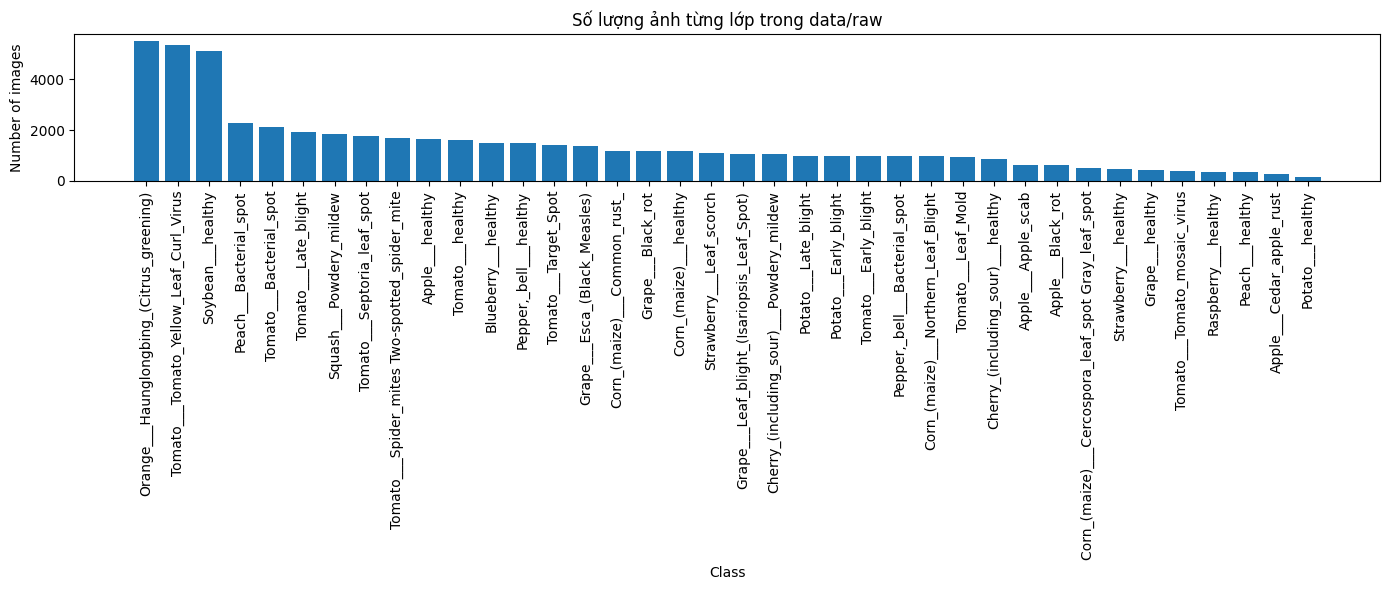

In [5]:
plt.figure(figsize=(14, 6))
plt.bar(df_raw['class_name'], df_raw['num_images'])
plt.xticks(rotation=90)
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.title('Số lượng ảnh từng lớp trong data/raw')
plt.tight_layout()
plt.show()

## 4. Hiển thị ảnh mẫu

Mục tiêu: kiểm tra ảnh có đúng là ảnh lá cây, có đúng nhãn, có ảnh lỗi rõ ràng hay không.

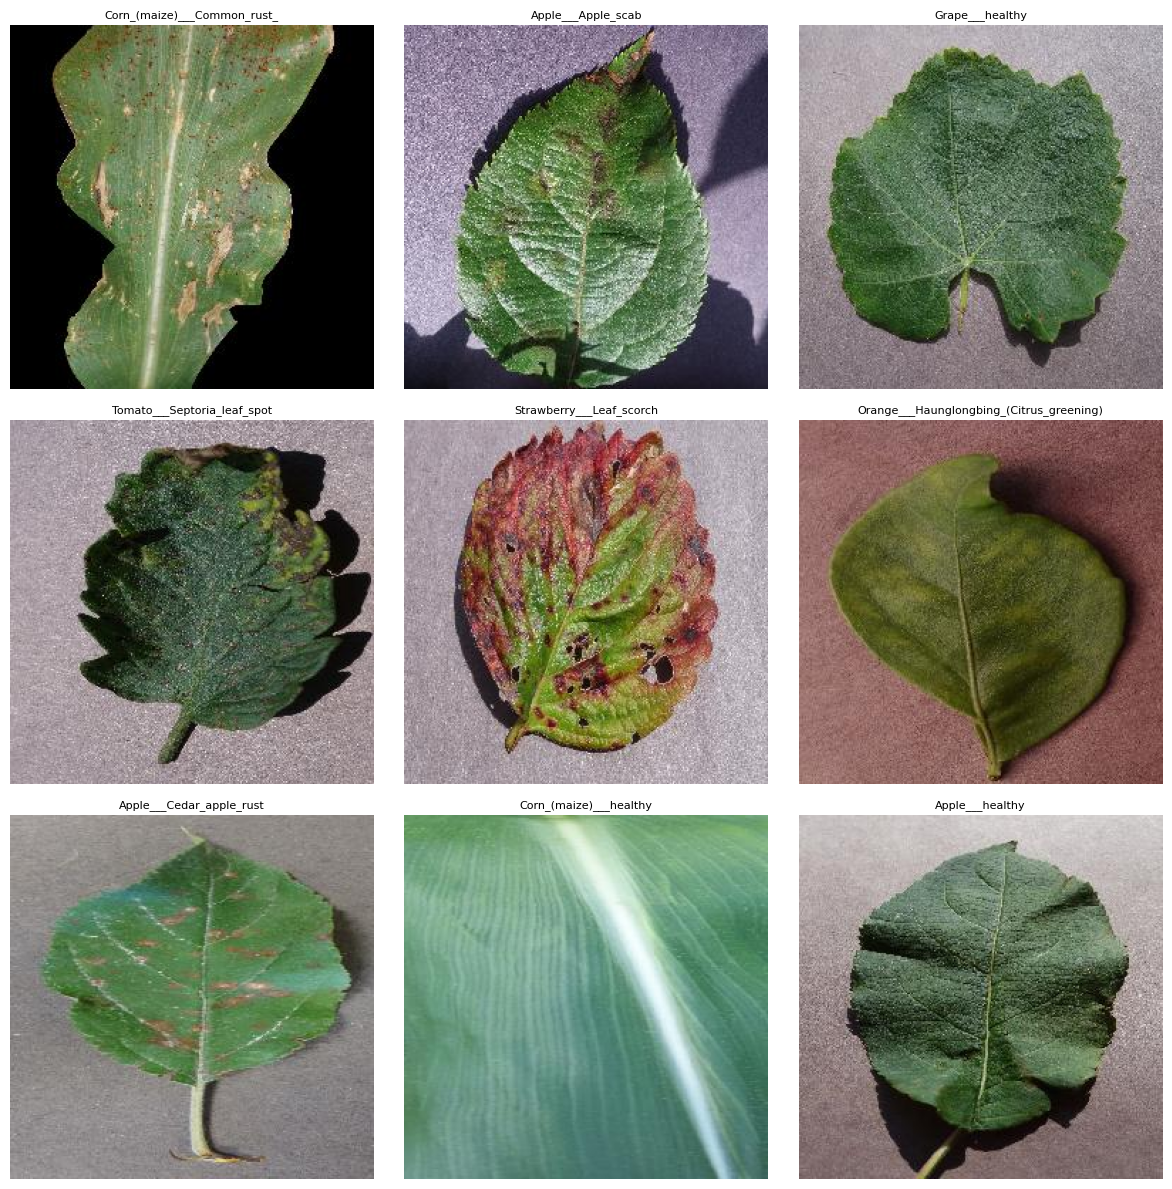

In [6]:
sample_classes = random.sample(class_dirs, min(9, len(class_dirs)))

plt.figure(figsize=(12, 12))
for i, class_dir in enumerate(sample_classes):
    images = [p for p in class_dir.glob('*') if p.suffix.lower() in image_extensions]
    img_path = random.choice(images)
    img = Image.open(img_path).convert('RGB')
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_dir.name, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Kiểm tra kích thước ảnh

Chỉ kiểm tra kích thước ảnh, chưa resize toàn bộ dataset. Resize chỉ được áp dụng sau khi chia dữ liệu thông qua `transforms`.

In [7]:
all_images = []
for class_dir in class_dirs:
    all_images.extend([p for p in class_dir.glob('*') if p.suffix.lower() in image_extensions])
sample_images = random.sample(all_images, min(1000, len(all_images)))

sizes = []
for img_path in sample_images:
    with Image.open(img_path) as img:
        sizes.append(img.size)
df_sizes = pd.DataFrame(sizes, columns=['width', 'height'])
df_sizes.describe()

,width,height
count,1000.0,1000.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


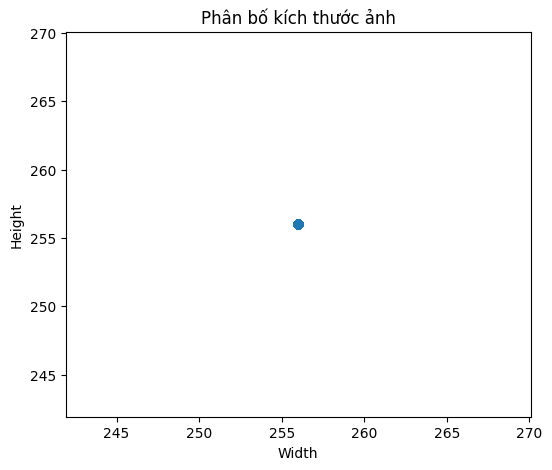

In [8]:
plt.figure(figsize=(6, 5))
plt.scatter(df_sizes['width'], df_sizes['height'], alpha=0.5)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Phân bố kích thước ảnh')
plt.show()

## 6. Kiểm tra ảnh lỗi
Nếu ảnh bị lỗi, PIL sẽ không mở được. Các ảnh lỗi nên được ghi nhận trước khi train.

In [9]:
broken_images = []

for img_path in all_images:
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception as e:
        broken_images.append((img_path, str(e)))
print('Số ảnh lỗi:', len(broken_images))
broken_images[:5]

Số ảnh lỗi: 0


[]

## 7. Kiểm tra dữ liệu đã chia train/val/test
Yêu cầu:
- Train: 80%
- Validation: 10%
- Test: 10%
- Chia trước tiền xử lý
- Có stratify

In [10]:
def count_split(split_dir):
    rows = []
    if not split_dir.exists():
        return pd.DataFrame(columns=['class_name', 'num_images'])
    
    for class_dir in split_dir.iterdir():
        if class_dir.is_dir():
            count = sum(1 for p in class_dir.glob('*') if p.suffix.lower() in image_extensions)
            rows.append({'class_name': class_dir.name, 'num_images': count})
    return pd.DataFrame(rows)

df_train = count_split(TRAIN_DIR)
df_val = count_split(VAL_DIR)
df_test = count_split(TEST_DIR)

print('Train:', df_train['num_images'].sum())
print('Val:', df_val['num_images'].sum())
print('Test:', df_test['num_images'].sum())

Train: 43444
Val: 5430
Test: 5431


In [11]:
total_split = df_train['num_images'].sum() + df_val['num_images'].sum() + df_test['num_images'].sum()

split_summary = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'num_images': [
        df_train['num_images'].sum(),
        df_val['num_images'].sum(),
        df_test['num_images'].sum()
    ]
})

split_summary['ratio'] = split_summary['num_images'] / total_split
split_summary

,split,num_images,ratio
0,train,43444,0.800000
1,val,5430,0.099991
2,test,5431,0.100009


## 8. Kiểm tra stratify

Nếu stratify đúng, tỷ lệ từng lớp trong train/val/test sẽ tương đối gần nhau.

In [12]:
df_check = df_raw.rename(columns={'num_images': 'raw_count'})

df_check = df_check.merge(df_train.rename(columns={'num_images': 'train_count'}), on='class_name', how='left')
df_check = df_check.merge(df_val.rename(columns={'num_images': 'val_count'}), on='class_name', how='left')
df_check = df_check.merge(df_test.rename(columns={'num_images': 'test_count'}), on='class_name', how='left')

df_check = df_check.fillna(0)

df_check['train_ratio'] = df_check['train_count'] / df_check['raw_count']
df_check['val_ratio'] = df_check['val_count'] / df_check['raw_count']
df_check['test_ratio'] = df_check['test_count'] / df_check['raw_count']

df_check.head(10)

,class_name,raw_count,train_count,val_count,test_count,train_ratio,val_ratio,test_ratio
0,Orange___Haunglongbing_(Citrus_greening),5507,4405,551,551,0.799891,0.100054,0.100054
1,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,4286,535,536,0.800075,0.099869,0.100056
2,Soybean___healthy,5090,4072,509,509,0.800000,0.100000,0.100000
3,Peach___Bacterial_spot,2297,1837,230,230,0.799739,0.100131,0.100131
4,Tomato___Bacterial_spot,2127,1702,212,213,0.800188,0.099671,0.100141
5,Tomato___Late_blight,1909,1527,191,191,0.799895,0.100052,0.100052
6,Squash___Powdery_mildew,1835,1468,183,184,0.800000,0.099728,0.100272
7,Tomato___Septoria_leaf_spot,1771,1417,177,177,0.800113,0.099944,0.099944
8,Tomato___Spider_mites Two-spotted_spider_mite,1676,1341,167,168,0.800119,0.099642,0.100239
9,Apple___healthy,1645,1316,164,165,0.800000,0.099696,0.100304


In [13]:
df_check[['train_ratio', 'val_ratio', 'test_ratio']].describe()

,train_ratio,val_ratio,test_ratio
count,38.000000,38.000000,38.000000
mean,0.800044,0.100115,0.099841
std,0.000557,0.000646,0.000515
min,0.798928,0.098684,0.098182
25%,0.799866,0.099795,0.099745
50%,0.800000,0.100000,0.100000
75%,0.800188,0.100120,0.100120
max,0.802632,0.101877,0.100671


## 9. Kết luận EDA

Sau EDA, cần ghi nhận vào báo cáo:

1. Tổng số ảnh.
2. Tổng số lớp bệnh.
3. Số ảnh mỗi lớp.
4. Dữ liệu có mất cân bằng lớp hay không.
5. Kích thước ảnh có đồng nhất hay không.
6. Có ảnh lỗi hay không.
7. Train/val/test có đúng 80/10/10 không.
8. Stratify có giữ tỷ lệ lớp tương đối giống nhau không.


Notebook này chỉ phục vụ phân tích dữ liệu, không dùng để train model chính thức.